# Praktikum K-Means Clustering
# Week/Sesi: 5/2 | Nama: Tika Altiora Sitanggang | NIM: 42324025

K-Means adalah algoritma *unsupervised learning* yang dipakai untuk klasterisasi, yaitu mengelompokkan data ke dalam beberapa klaster berdasarkan kemiripan karakteristiknya. Berbeda dengan KNN atau Naive Bayes yang butuh label, K-Means tidak butuh label. Algoritma ini yang mencari sendiri pola kelompok di dalam data.

Cara kerja K-Means (versi sederhana):
1. Tentukan jumlah klaster k.
2. Pilih k titik pusat (centroid) awal secara acak.
3. Setiap data dimasukkan ke klaster dengan centroid terdekat (pakai jarak Euclidean).
4. Hitung ulang posisi centroid = rata-rata semua data di klaster tersebut.
5. Ulangi langkah 3 dan 4 sampai centroid tidak berubah lagi (konvergen).

Bagaimana menentukan k yang tepat? Pakai Elbow Method. Kita hitung WCSS (*Within-Cluster Sum of Squares*, jumlah kuadrat jarak tiap data ke centroid klasternya) untuk k = 1 sampai 10, lalu cari titik "siku" di grafik, yaitu titik setelah penurunan WCSS mulai landai.

Alur praktikum ini:
- Bagian 1: Klasterisasi 2 fitur (Annual Income dan Spending Score)
- Bagian 2: Klasterisasi 3 fitur (Age, Annual Income, dan Spending Score)
- Bagian 3: Tugas (profil klaster, validasi dengan Silhouette Score, dan pengaruh scaling)
- Bagian 4: Kesimpulan

# Bagian 1. Klasterisasi dengan 2 Fitur

Proses klasterisasi difokuskan dulu pada dua fitur utama, yaitu Annual Income dan Spending Score. Alasannya supaya mudah dipahami dan mudah divisualisasikan dalam grafik 2 dimensi, sebelum nanti ditambah fitur lainnya.

## 1.1 Import Library dan Load Dataset

Dataset Mall_Customers.csv berisi data 200 pelanggan mall: `CustomerID`, `Genre` (jenis kelamin), `Age`, `Annual Income (k$)`, dan `Spending Score (1-100)`.

- `pd.read_csv()` membaca file CSV menjadi DataFrame.
- `df.head()` menampilkan 5 baris pertama untuk melihat bentuk datanya.

> Catatan: di modul, path-nya `/content/Mall_Customers.csv` (Google Colab). Karena di VS Code file CSV-nya satu folder dengan notebook, saya pakai path relatif `Mall_Customers.csv`.

In [1]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Penjelasan hasil:** Tabel menampilkan 5 pelanggan pertama. Ada 5 kolom. `CustomerID` hanya nomor identitas, `Genre` bertipe teks (kategorikal), sedangkan `Age`, `Annual Income (k$)`, dan `Spending Score (1-100)` bertipe angka. Kolom angka inilah yang cocok dipakai untuk K-Means karena K-Means menghitung jarak.

## 1.2 Cek Missing Values

Sebelum klasterisasi, kita pastikan tidak ada data kosong. `df.isnull().sum()` menghitung jumlah nilai kosong (*missing value*) di setiap kolom. K-Means tidak bisa jalan kalau ada nilai kosong.

In [2]:
# cek missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Penjelasan hasil: Semua kolom bernilai 0, artinya tidak ada missing value. Data sudah bersih dan bisa langsung dipakai tanpa perlu imputasi atau penghapusan baris.

## 1.3 Statistik Deskriptif

`df.describe()` menampilkan ringkasan statistik tiap kolom angka (jumlah data, rata-rata, standar deviasi, min, kuartil, dan max). Ini berguna untuk memahami sebaran dan skala tiap fitur.

In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Penjelasan hasil:**
- Jumlah data = 200 pelanggan.
- `Age`: rata-rata sekitar 38,85 tahun (rentang 18 sampai 70).
- `Annual Income (k$)`: rata-rata sekitar 60,56 (rentang 15 sampai 137).
- `Spending Score (1-100)`: rata-rata 50,2 (rentang 1 sampai 99).
- Skala `Annual Income` (sampai 137) dan `Spending Score` (sampai 99) tidak jauh beda, tapi tetap berbeda. Karena K-Means berbasis jarak, fitur dengan rentang lebih besar bisa lebih dominan. Inilah alasan nanti kita melakukan scaling.

## 1.4 Memilih Fitur untuk Klasterisasi

`df.iloc[:, 3:]` mengambil semua baris dan kolom mulai dari indeks 3 sampai terakhir, yaitu `Annual Income (k$)` dan `Spending Score (1-100)`. Hasilnya disimpan di variabel `dataset`.

In [4]:
dataset = df.iloc[:,3:]
dataset.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**Penjelasan hasil:** Sekarang `dataset` hanya berisi 2 kolom yang akan dipakai untuk klasterisasi tahap awal. Kolom `CustomerID`, `Genre`, dan `Age` tidak ikut dipakai dulu.

## 1.5 Menyiapkan Variabel x dan y

Untuk keperluan visualisasi, kolom `Annual Income` dipisah sebagai **x** (indeks 3) dan `Spending Score` sebagai **y** (indeks 4).

In [5]:
x = df.iloc[:, 3]
y = df.iloc[:, 4]

**Penjelasan:** Sel ini tidak menampilkan output karena hanya membuat variabel. `x` dan `y` dipakai untuk membuat scatter plot di sel berikutnya.

## 1.6 Visualisasi Sebaran Data (Scatter Plot)

Sebelum klasterisasi, kita lihat dulu bentuk sebaran datanya dengan `plt.scatter(x, y)`. Dari sini kita bisa menebak apakah data memang punya kelompok yang terlihat.

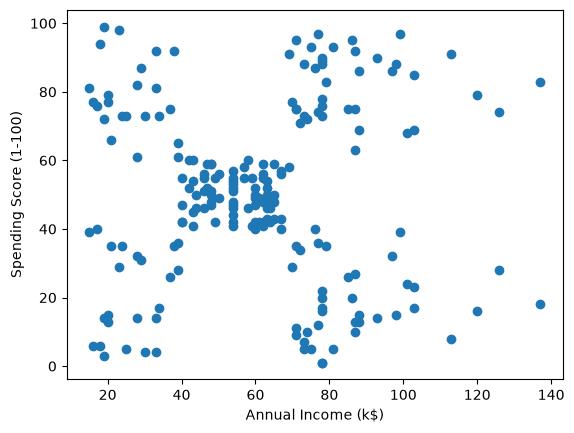

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

Gambar 1. Sebaran data Annual Income terhadap Spending Score

Penjelasan hasil: Dari scatter plot terlihat data sudah membentuk kelompok secara alami. Ada satu kelompok besar di tengah (income sedang, score sedang), lalu kelompok di sudut kiri atas (income rendah, score tinggi), kiri bawah (income rendah, score rendah), kanan atas (income tinggi, score tinggi), dan kanan bawah (income tinggi, score rendah). Secara visual kira-kira ada 5 kelompok. Nanti kita buktikan dengan Elbow Method.

## 1.7 Scaling Data dan Elbow Method

Langkah di sel ini:
1. MinMaxScaler mengubah semua fitur ke rentang 0 sampai 1 supaya tidak ada fitur yang mendominasi perhitungan jarak. Rumusnya: `x_scaled = (x - min) / (max - min)`.
2. Bentuk DataFrame `X` dari `x` dan `y`, lalu di-scaling jadi `X_scaled`.
3. Elbow Method: jalankan K-Means untuk k = 1 sampai 10, simpan nilai `inertia_` (= WCSS) tiap k ke list `wcss`.
4. Plot k terhadap WCSS dan cari titik siku.

`random_state=42` dipakai supaya hasilnya selalu sama setiap dijalankan.

c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

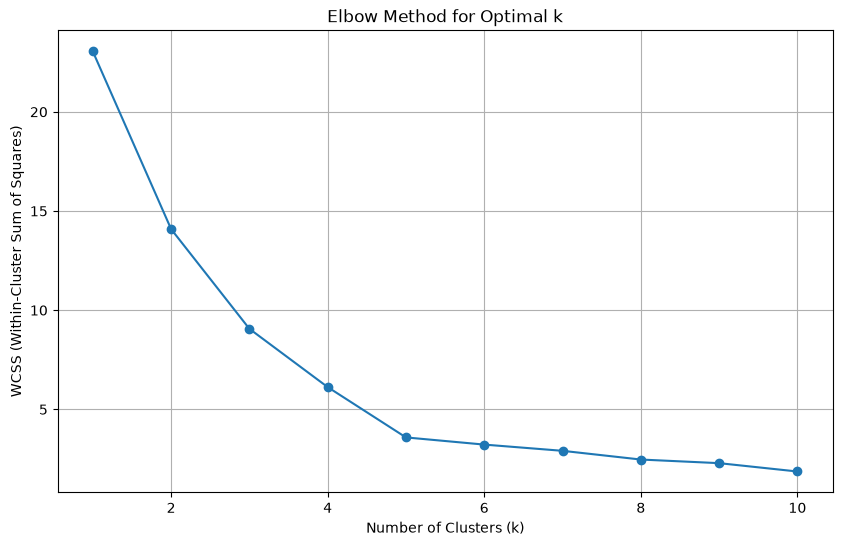

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()

# Mengambil kolom X (index 3) dan Y (index 4) dari DataFrame
X = pd.DataFrame({'Annual Income (k$)': x, 'Spending Score (1-100)': y})

X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal menggunakan Elbow Method
wcss = []
for i in range(1, 11):  # Coba k dari 1 sampai 10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Membuat plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

*Gambar 2. Grafik Elbow Method untuk 2 fitur*

Penjelasan hasil: WCSS turun tajam dari k=1 (sekitar 23) sampai k=5 (sekitar 3,6). Setelah k=5, penurunannya jadi sangat landai (k=6 sekitar 3,2, k=7 sekitar 2,9, dan seterusnya). Titik "siku" ada di k = 5. Artinya menambah klaster lebih dari 5 tidak memberi perbaikan yang berarti, jadi k optimal = 5. Ini cocok dengan dugaan dari scatter plot tadi.

## 1.8 Membentuk Klaster dengan k = 5

Dari Elbow Method, k optimal = 5. Maka:
- `KMeans(n_clusters=5)` membuat model dengan 5 klaster.
- `kmeans.fit(X)` melatih model pada data.
- `kmeans.labels_` berisi nomor klaster (0 sampai 4) untuk tiap pelanggan, dipakai sebagai warna di scatter plot (`c=kmeans.labels_`).

> Catatan: saya tambahkan `random_state=42` supaya nomor/warna klaster tidak berubah-ubah tiap dijalankan. Tanpa `random_state`, centroid awal dipilih acak sehingga urutan nomor klaster bisa berbeda (walaupun kelompoknya tetap sama).

c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


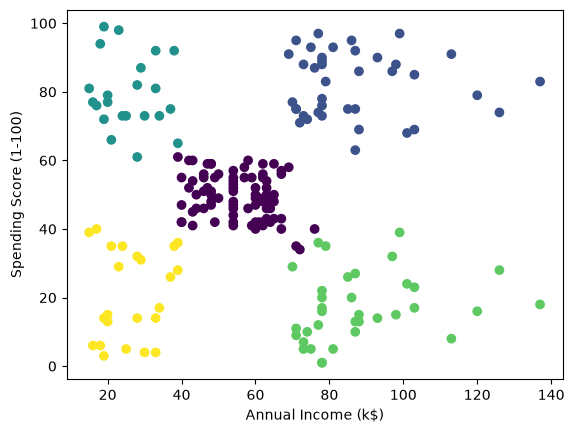

In [8]:
# dari elbow method, nilai k optimal untuk data ini adalah 5
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Plot hasil klaster
plt.scatter(x, y, c=kmeans.labels_)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

Gambar 3. Hasil klasterisasi K-Means (k=5) pada Annual Income dan Spending Score

Penjelasan hasil: Data terbagi menjadi 5 klaster dengan warna berbeda yang terpisah jelas:
- Klaster di tengah: income sedang, spending score sedang (pelanggan "standar").
- Klaster kanan atas: income tinggi, spending score tinggi.
- Klaster kiri atas: income rendah, spending score tinggi.
- Klaster kanan bawah: income tinggi, spending score rendah.
- Klaster kiri bawah: income rendah, spending score rendah.

Pembagian ini sesuai dengan bentuk kelompok yang terlihat di Gambar 1, jadi hasil klasterisasinya masuk akal.

# Bagian 2. Klasterisasi dengan 3 Fitur

Selanjutnya klasterisasi dilakukan dengan tiga fitur utam, yaitu Age, Annual Income, dan Spending Score. Karena ada 3 fitur, visualisasinya memakai grafik 3 dimensi.

## 2.1 Visualisasi Data 3D

- `x`, `y`, `z` sekarang diisi `Age` (indeks 2), `Annual Income` (indeks 3), dan `Spending Score` (indeks 4).
- `fig.add_subplot(111, projection='3d')` membuat kanvas 3D.
- `ax.scatter(x, y, z, ...)` menggambar titik di ruang 3D. Semua titik berwarna merah karena belum diklaster.

> Perhatian: variabel `x` dan `y` di sini menimpa nilai `x` dan `y` dari Bagian 1.

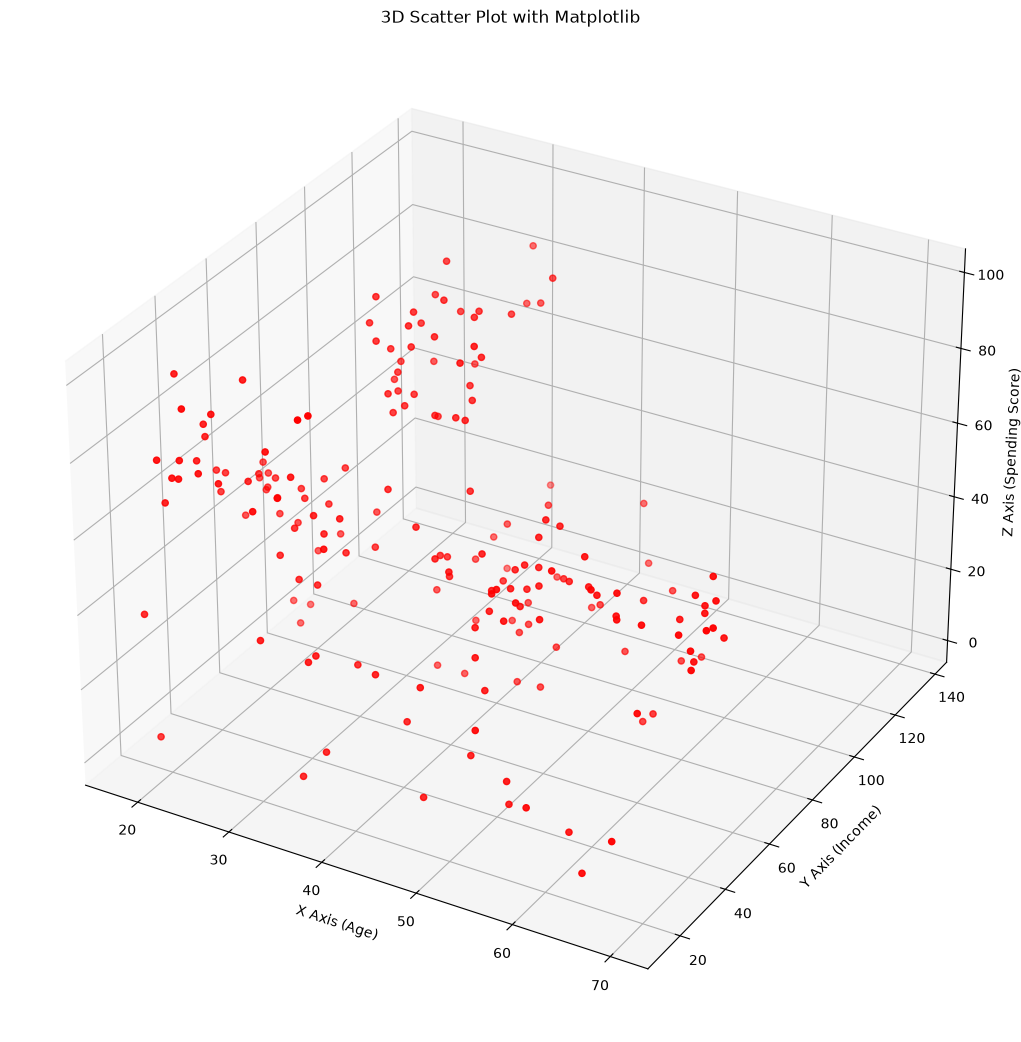

In [9]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Data Age, Annual Income, dan Spending Score
x = df.iloc[:, 2]
y = df.iloc[:, 3]
z = df.iloc[:, 4]

# Membuat plot 3D
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot data
ax.scatter(x, y, z, c='red', marker='o')

# Label sumbu
ax.set_xlabel('X Axis (Age)')
ax.set_ylabel('Y Axis (Income)')
ax.set_zlabel('Z Axis (Spending Score)')

plt.title('3D Scatter Plot with Matplotlib')
plt.show()

*Gambar 4. Scatter plot 3D Age, Annual Income, dan Spending Score*

**Penjelasan hasil:** Dengan tambahan dimensi Age, sebaran data jadi lebih rumit dibanding versi 2D. Kelompoknya tidak sejelas sebelumnya karena ada tumpang tindih antar titik. Kita masih bisa melihat pelanggan muda cenderung punya spending score tinggi, dan pelanggan yang lebih tua cenderung berada di spending score sedang sampai rendah. Karena sulit ditebak dengan mata, kita pakai Elbow Method untuk menentukan k.

## 2.2 Scaling dan Elbow Method (3 Fitur)

- `np.array(list(zip(x, y, z)))` menggabungkan 3 kolom menjadi satu array `X` berukuran 200 x 3.
- Data di-scaling dengan MinMaxScaler. Ini penting karena `Age` (18 sampai 70) dan `Annual Income` (15 sampai 137) punya rentang berbeda.
- Hitung WCSS untuk k = 1 sampai 10 seperti sebelumnya.

c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

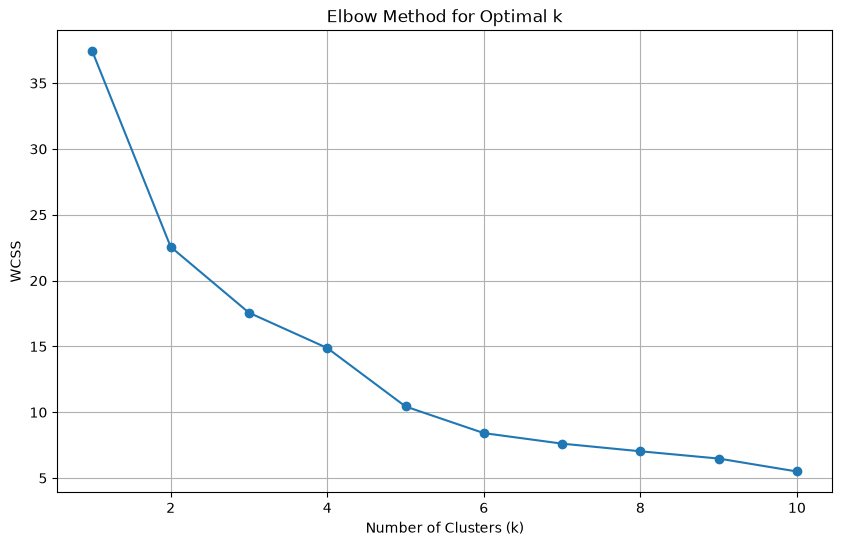

In [10]:
# Menggabungkan data X, Y, Z menjadi array untuk clustering
X = np.array(list(zip(x, y, z)))

# Scaling data dengan MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Menentukan jumlah klaster optimal dengan Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

*Gambar 5. Grafik Elbow Method untuk 3 fitur*

Penjelasan hasil: WCSS turun dari sekitar 37,4 (k=1) ke sekitar 10,4 (k=5), lalu ke sekitar 8,4 (k=6). Setelah k=6, penurunannya makin kecil (k=7 sekitar 7,6, k=8 sekitar 7,0). Siku di grafik ini tidak setajam pada versi 2 fitur karena datanya lebih menyebar, tapi bentuk landai mulai terlihat sekitar k = 5 sampai 6. Praktikum memilih k = 6. Nanti di Bagian 3 kita cek pilihan ini dengan Silhouette Score.

## 2.3 Membentuk Klaster dengan k = 6 dan Visualisasi 3D

Langkah di sel ini:
- `KMeans(n_clusters=6, random_state=42)` membuat model dengan 6 klaster.
- `fit_predict(X)` sekaligus melatih model dan mengembalikan nomor klaster tiap pelanggan.
- `df['Cluster'] = clusters` menambahkan hasil klaster sebagai kolom baru di DataFrame.
- Scatter plot 3D diwarnai berdasarkan klaster (`c=clusters`, `cmap='viridis'`) dan diberi legenda.

> Catatan: pada modul, Elbow dihitung dari data yang sudah di-scaling (`X_scaled`), tetapi model akhir di-*fit* pada `X` (data asli, belum di-scaling). Saya tulis sesuai modul, lalu pengaruh perbedaannya dibahas di Bagian 3 (Tugas 3).

c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


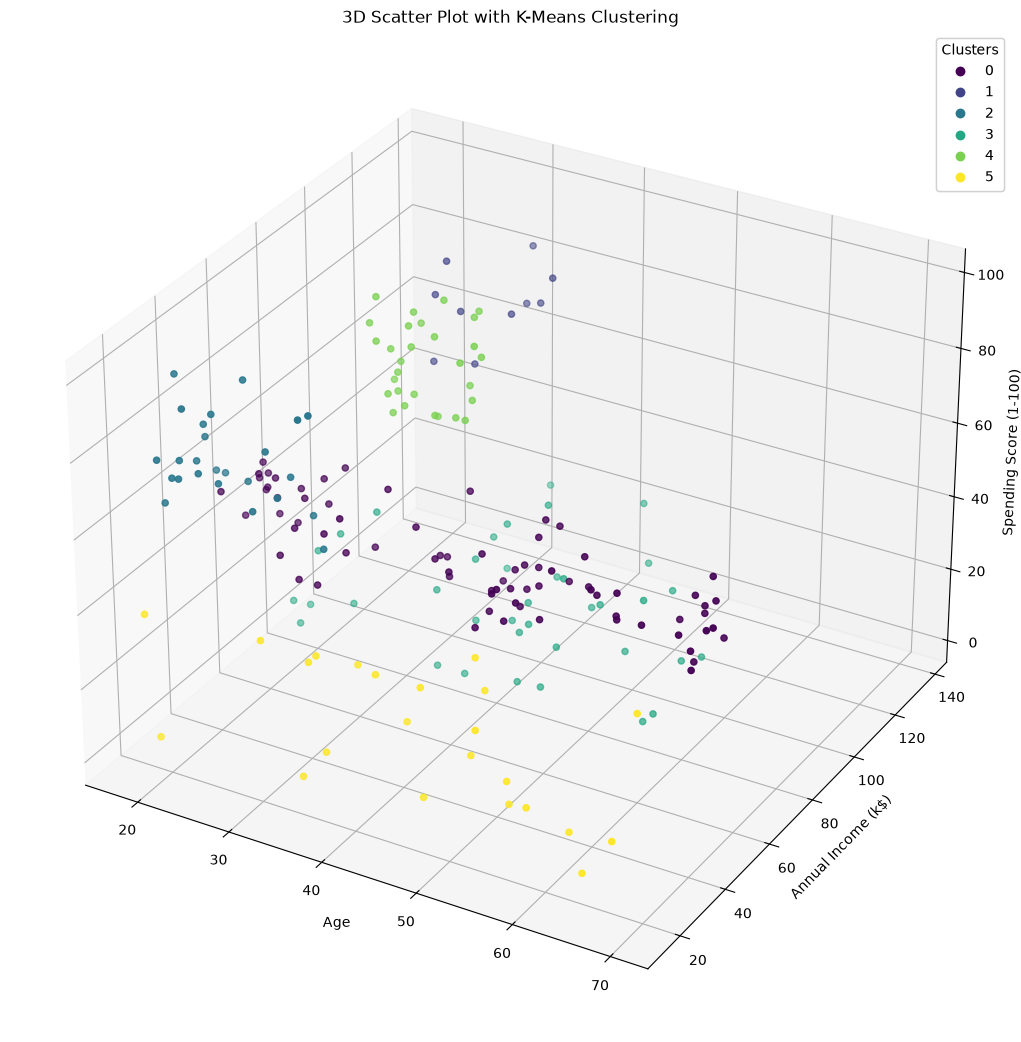

In [11]:
# Pilih k optimal setelah melihat Elbow
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X)

# Menambahkan hasil klaster ke DataFrame
df['Cluster'] = clusters


# Visualisasi 3D Hasil K-Means

# Plot data dengan warna berdasarkan klaster
fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

# Plot setiap titik dengan warna sesuai klaster
scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis', marker='o')

# Label sumbu
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

# Menampilkan legenda klaster
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.title('3D Scatter Plot with K-Means Clustering')
plt.show()

*Gambar 6. Hasil klasterisasi K-Means (k=6) pada Age, Annual Income, dan Spending Score*

Penjelasan hasil: Pelanggan terbagi menjadi 6 klaster (nomor 0 sampai 5) yang masing-masing punya warna sendiri. Kolom `Cluster` juga sudah tersimpan di `df`, jadi bisa dipakai untuk analisis profil di Bagian 3. Perhatikan bahwa pada versi 3 fitur, klaster tidak hanya dibedakan oleh income dan spending score, tapi juga oleh umur. Misalnya klaster dengan income dan score yang mirip bisa dipisah karena rentang umurnya berbeda.

# Bagian 3. Tugas

Bagian saya buat untuk menjawab pertanyaan analisis dari hasil praktikum:
1. Seperti apa profil tiap klaster pada klasterisasi 2 fitur (k=5)?
2. Seperti apa profil tiap klaster pada klasterisasi 3 fitur (k=6)?
3. Apakah pilihan k sudah tepat? Validasi dengan Silhouette Score.
4. Apa pengaruh scaling terhadap hasil klaster?

> Catatan: nomor klaster (0, 1, 2, ...) hanyalah label dan bisa berbeda urutannya di komputer lain. Yang penting adalah profil/karakteristiknya, bukan nomornya.

## Tugas 1. Profil Klaster pada 2 Fitur (k = 5)

Model dilatih ulang pada kolom `Annual Income` dan `Spending Score` (karena variabel `kmeans`, `x`, `y` sebelumnya sudah tertimpa oleh Bagian 2). Lalu kita ambil:
- `cluster_centers_` = posisi centroid tiap klaster (dalam satuan asli),
- jumlah anggota tiap klaster,
- nama segmen otomatis berdasarkan level income dan spending score.

Aturan level: income rendah < 40, tinggi > 70, selain itu sedang. Spending score rendah < 40, tinggi > 60, selain itu sedang.

In [12]:
fitur_2d = ['Annual Income (k$)', 'Spending Score (1-100)']
X2 = df[fitur_2d]

km2 = KMeans(n_clusters=5, random_state=42)
df['Cluster_2D'] = km2.fit_predict(X2)

# Tabel profil klaster (centroid dalam satuan asli + jumlah anggota)
profil_2d = pd.DataFrame(km2.cluster_centers_, columns=fitur_2d).round(1)
profil_2d['Jumlah Pelanggan'] = df['Cluster_2D'].value_counts().sort_index().values

def beri_nama(inc, sp):
    lv_inc = 'rendah' if inc < 40 else ('tinggi' if inc > 70 else 'sedang')
    lv_sp = 'rendah' if sp < 40 else ('tinggi' if sp > 60 else 'sedang')
    nama = {
        ('sedang', 'sedang'): 'Standar',
        ('tinggi', 'tinggi'): 'Target Utama',
        ('rendah', 'tinggi'): 'Impulsif',
        ('tinggi', 'rendah'): 'Hemat',
        ('rendah', 'rendah'): 'Berhati-hati',
    }
    return nama.get((lv_inc, lv_sp), f'Income {lv_inc}, Score {lv_sp}')

profil_2d['Segmen'] = [beri_nama(i, s) for i, s in zip(profil_2d[fitur_2d[0]], profil_2d[fitur_2d[1]])]
profil_2d.index.name = 'Cluster'
profil_2d

c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Annual Income (k$),Spending Score (1-100),Jumlah Pelanggan,Segmen
Cluster,,,,
0,55.3,49.5,81,Standar
1,86.5,82.1,39,Target Utama
2,25.7,79.4,22,Impulsif
3,88.2,17.1,35,Hemat
4,26.3,20.9,23,Berhati-hati


**Penjelasan hasil:** Tabel menunjukkan centroid (rata-rata) tiap klaster. Kelima segmen yang terbentuk:

| Segmen | Income | Spending Score | Jumlah | Arti bisnis |
|---|---|---|---|---|
| **Standar** | sekitar 55 | sekitar 50 | 81 | Kelompok terbesar, pelanggan "biasa" |
| **Target Utama** | sekitar 86 | sekitar 82 | 39 | Mampu dan suka belanja, prioritas promosi |
| **Impulsif** | sekitar 26 | sekitar 79 | 22 | Income kecil tapi belanja banyak, cocok untuk diskon atau cicilan |
| **Hemat** | sekitar 88 | sekitar 17 | 35 | Mampu tapi jarang belanja, potensi besar kalau ditarik dengan program khusus |
| **Berhati-hati** | sekitar 26 | sekitar 21 | 23 | Income kecil dan belanja kecil, sulit jadi target utama |

Jumlah anggota bisa bergeser 1 sampai 2 pelanggan tergantung versi library, tapi profilnya tetap sama.

Selanjutnya kita gambar hasil klaster beserta centroid-nya (tanda X merah) supaya lebih jelas letak pusat tiap klaster.

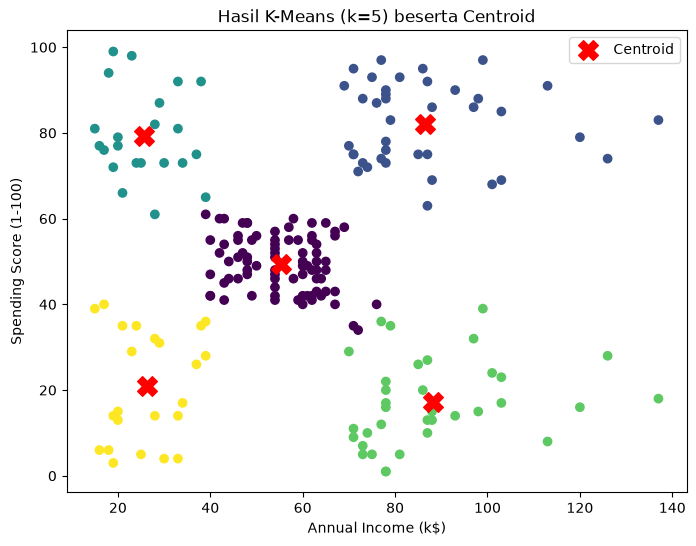

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(df[fitur_2d[0]], df[fitur_2d[1]], c=df['Cluster_2D'], cmap='viridis')
plt.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.title('Hasil K-Means (k=5) beserta Centroid')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Gambar 7. Hasil klaster 2 fitur beserta posisi centroid

Penjelasan hasil: Tanda X merah adalah centroid, yaitu titik rata-rata tiap klaster. Setiap centroid berada tepat di tengah kelompok warnanya. Kelima klaster terpisah dengan jelas dan hampir tidak ada titik yang tercampur, tanda bahwa K-Means bekerja sangat baik pada 2 fitur ini.

## Tugas 2. Profil Klaster pada 3 Fitur (k = 6)

Pakai kolom `Cluster` dari hasil Bagian 2. Kita kelompokkan dengan `groupby('Cluster')` lalu hitung jumlah anggota dan rata-rata Age, Annual Income, dan Spending Score. Kolom `Genre` ditambahkan sebagai pelengkap untuk melihat proporsi perempuan di tiap klaster.

In [14]:
profil_3d = df.groupby('Cluster').agg(
    Jumlah=('Age', 'size'),
    Rata_Age=('Age', 'mean'),
    Rata_Income=('Annual Income (k$)', 'mean'),
    Rata_Spending=('Spending Score (1-100)', 'mean'),
    Persen_Perempuan=('Genre', lambda s: (s == 'Female').mean() * 100)
).round(1)
profil_3d

,Jumlah,Rata_Age,Rata_Income,Rata_Spending,Persen_Perempuan
Cluster,,,,,
0,76,43.9,55.2,49.4,59.2
1,10,32.2,109.7,82.0,60.0
2,25,25.0,28.0,77.0,56.0
3,37,40.3,87.4,18.2,48.6
4,29,32.9,78.6,82.2,51.7
5,23,45.2,26.3,20.9,60.9


*Penjelasan hasil:* Profil 6 klaster pada 3 fitur (angka bisa sedikit berbeda di tiap komputer, tapi polanya sama):

| Profil | Umur | Income | Spending | Jumlah | Interpretasi |
|---|---|---|---|---|---|
| A | sekitar 44 | sekitar 55 | sekitar 49 | 76 | Paruh baya, income dan belanja sedang. Kelompok terbesar. |
| B | sekitar 32 | sekitar 110 | sekitar 82 | 10 | Muda, income sangat tinggi, belanja tinggi. Kelompok kecil tapi paling bernilai. |
| C | sekitar 25 | sekitar 28 | sekitar 77 | 25 | Sangat muda, income kecil tapi belanja tinggi. |
| D | sekitar 40 | sekitar 87 | sekitar 18 | 37 | Income tinggi tapi belanja rendah (pelanggan hemat). |
| E | sekitar 33 | sekitar 79 | sekitar 82 | 29 | Muda, income tinggi, belanja tinggi. |
| F | sekitar 45 | sekitar 26 | sekitar 21 | 23 | Lebih tua, income kecil dan belanja kecil. |

Hal menarik: Pada versi 2 fitur, kelompok "income tinggi dan belanja tinggi" hanya satu klaster. Pada versi 3 fitur, kelompok itu terpecah dua (B dan E) berdasarkan tingkat income. Ini bukti bahwa menambah fitur `Age` membuat segmentasi lebih detail. Secara umum, pelanggan muda cenderung berbelanja lebih banyak, sedangkan pelanggan lebih tua cenderung berbelanja sedang sampai rendah.

## Tugas 3. Validasi Pilihan k dengan Silhouette Score

Elbow Method terkadang subjektif karena "siku"-nya bisa terlihat berbeda bagi tiap orang. Jadi kita validasi dengan Silhouette Score.

- Nilainya berkisar -1 sampai 1.
- Makin mendekati 1, makin baik: data dekat dengan klasternya sendiri dan jauh dari klaster lain.
- Nilai di sekitar 0 artinya klaster saling tumpang tindih.

Kita hitung untuk k = 2 sampai 10 pada data ter-scaling, baik untuk 2 fitur maupun 3 fitur.

c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

,k,Silhouette 2 Fitur,Silhouette 3 Fitur
0,2,0.345,0.365
1,3,0.450,0.340
2,4,0.497,0.366
3,5,0.559,0.404
4,6,0.524,0.419
5,7,0.481,0.421
6,8,0.474,0.367
7,9,0.433,0.363
8,10,0.448,0.366


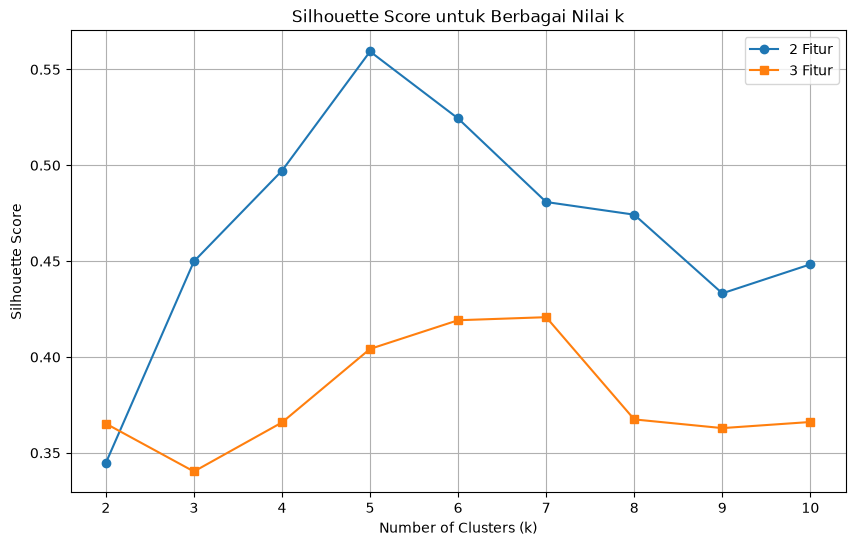

In [15]:
from sklearn.metrics import silhouette_score

X2_scaled = MinMaxScaler().fit_transform(df[fitur_2d])
X3_scaled = MinMaxScaler().fit_transform(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])

rentang_k = range(2, 11)
sil_2d = [silhouette_score(X2_scaled, KMeans(n_clusters=k, random_state=42).fit_predict(X2_scaled)) for k in rentang_k]
sil_3d = [silhouette_score(X3_scaled, KMeans(n_clusters=k, random_state=42).fit_predict(X3_scaled)) for k in rentang_k]

hasil_sil = pd.DataFrame({'k': list(rentang_k), 'Silhouette 2 Fitur': sil_2d, 'Silhouette 3 Fitur': sil_3d}).round(3)
display(hasil_sil)

plt.figure(figsize=(10, 6))
plt.plot(rentang_k, sil_2d, marker='o', label='2 Fitur')
plt.plot(rentang_k, sil_3d, marker='s', label='3 Fitur')
plt.title('Silhouette Score untuk Berbagai Nilai k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.legend()
plt.show()

*Gambar 8. Silhouette Score untuk k = 2 sampai 10*

Penjelasan hasil
- 2 fitur: Silhouette tertinggi ada di k = 5 (sekitar 0,559). Ini sejalan dengan hasil Elbow Method, jadi pilihan k=5 sudah tepat. Nilai 0,559 tergolong baik (klaster cukup terpisah jelas).
- 3 fitur: Silhouette tertinggi di k = 7 (sekitar 0,421), sedangkan k = 6 (sekitar 0,419) hampir sama. Selisihnya sangat kecil, sehingga pilihan k = 6 dari modul tetap masuk akal dan lebih ringkas.
- Nilai silhouette 3 fitur (sekitar 0,42) lebih rendah daripada 2 fitur (sekitar 0,56). Artinya struktur klaster pada 3 fitur lebih tumpang tindih, wajar karena datanya menyebar di lebih banyak dimensi.

## Tugas 4. Pengaruh Scaling terhadap Hasil Klaster

Di modul, model akhir 3 fitur dilatih pada data asli (`X`), sedangkan Elbow dihitung dari data ter-scaling. Di sel ini kita bandingkan dua pendekatan:
1. K-Means pada data asli (tanpa scaling),
2. K-Means pada data ter-scaling (MinMaxScaler).

Pembandingan memakai:
- Silhouette Score pada ruang data ter-scaling (supaya adil, semua dinilai dengan "penggaris" yang sama),
- Adjusted Rand Index (ARI) untuk melihat seberapa mirip dua hasil pengelompokan (1 = identik, 0 = acak).

In [16]:
from sklearn.metrics import adjusted_rand_score

X3_asli = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

label_asli = KMeans(n_clusters=6, random_state=42).fit_predict(X3_asli)
label_scaled = KMeans(n_clusters=6, random_state=42).fit_predict(X3_scaled)

perbandingan = pd.DataFrame({
    'Pendekatan': ['Tanpa scaling (sesuai modul)', 'Dengan MinMaxScaler'],
    'Silhouette (ruang ter-scaling)': [silhouette_score(X3_scaled, label_asli),
                                       silhouette_score(X3_scaled, label_scaled)],
    'Jumlah per klaster': [sorted(np.bincount(label_asli), reverse=True),
                           sorted(np.bincount(label_scaled), reverse=True)]
})
display(perbandingan.round(3))
print('Adjusted Rand Index kedua hasil:', round(adjusted_rand_score(label_asli, label_scaled), 3))

c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tikas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Pendekatan,Silhouette (ruang ter-scaling),Jumlah per klaster
0,Tanpa scaling (sesuai modul),0.276,"[76, 37, 29, 25, 23, 10]"
1,Dengan MinMaxScaler,0.419,"[45, 44, 40, 33, 22, 16]"


Adjusted Rand Index kedua hasil: 0.578


**Penjelasan hasil:**
- Silhouette tanpa scaling (sekitar 0,276) lebih rendah dibanding dengan scaling (sekitar 0,419). Jadi hasil dengan scaling membentuk klaster yang lebih rapi dan terpisah.
- Ukuran klaster juga berbeda. Tanpa scaling ukurannya timpang (ada klaster berisi 76 pelanggan dan ada yang cuma 10), sedangkan dengan scaling ukurannya lebih seimbang (antara 16 sampai 45).
- ARI sekitar 0,58, artinya kedua hasil hanya mirip sebagian, bukan identik.

Alasannya: tanpa scaling, fitur dengan rentang besar (`Annual Income` sampai 137) lebih mendominasi jarak dibanding `Age` (18 sampai 70). Setelah di-scaling ke 0 sampai 1, ketiga fitur punya bobot yang setara. Kesimpulannya, scaling sangat disarankan untuk K-Means, dan akan lebih konsisten kalau model akhir juga dilatih pada `X_scaled` (bukan `X`) seperti saat menghitung Elbow.

# Bagian 4. Kesimpulan

1. K-Means adalah algoritma unsupervised learning yang mengelompokkan data berdasarkan jarak ke centroid, tanpa memerlukan label.
2. Dataset Mall Customers (200 pelanggan) tidak punya missing value, sehingga siap dipakai.
3. Pada 2 fitur (Annual Income dan Spending Score), Elbow Method dan Silhouette Score sama-sama menunjuk k = 5. Terbentuk 5 segmen: Standar, Target Utama, Impulsif, Hemat, dan Berhati-hati.
4. Pada 3 fitur (ditambah Age), dipilih k = 6. Silhouette Score untuk k=6 (sekitar 0,419) hampir sama dengan k=7 (sekitar 0,421), jadi pilihan ini cukup baik. Tambahan fitur Age membuat segmentasi lebih detail, misalnya kelompok income tinggi dan belanja tinggi terpecah dua.
5. Scaling berpengaruh besar. Hasil dengan MinMaxScaler membentuk klaster yang lebih rapi (silhouette sekitar 0,419 dibanding 0,276 tanpa scaling).
6. Dari sisi bisnis, segmen Target Utama cocok untuk promosi produk premium, segmen Impulsif cocok untuk diskon atau cicilan, dan segmen Hemat perlu program khusus supaya mau berbelanja lebih banyak.